In [3]:
# Celda 1: Importar las librerías necesarias
import json
import os
import shutil
import cv2  # OpenCV para leer las imágenes
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm  # Para barras de progreso
import numpy as np
import warnings

print("Librerías importadas exitosamente.")

Librerías importadas exitosamente.


In [4]:
# Celda 2: ⚙️ Configuración de Rutas
# --- MODIFICA ESTAS DOS LÍNEAS ---
# Ruta a la carpeta que contiene TUS imágenes y archivos JSON originales
RUTA_ORIGEN = Path(r"C:\Universidad\Seminario\Roberto_Plates\V5\dataset_small_v7")

# Ruta donde se creará el nuevo dataset formateado para YOLO
RUTA_SALIDA_YOLO = Path(r"C:\Universidad\Seminario\Roberto_Plates\V5\dataset_yolo")
# ------------------------------------

# Porcentaje de datos para validación (ej. 0.2 = 20%)
PORCENTAJE_VALIDACION = 0.2

# Asegurémonos de que la carpeta de origen exista
if not RUTA_ORIGEN.exists():
    print(f"¡Error! La carpeta de origen no existe: {RUTA_ORIGEN}")
    print("Por favor, corrige la ruta en RUTA_ORIGEN y vuelve a ejecutar.")
    # Creamos una carpeta de ejemplo para que el resto del script no falle
    RUTA_ORIGEN.mkdir(parents=True, exist_ok=True)
else:
    print(f"Carpeta de origen encontrada: {RUTA_ORIGEN}")

# Limpiar la carpeta de salida si ya existe
if RUTA_SALIDA_YOLO.exists():
    print(f"Borrando carpeta de salida antigua: {RUTA_SALIDA_YOLO}")
    shutil.rmtree(RUTA_SALIDA_YOLO)

print(f"La nueva carpeta del dataset se creará en: {RUTA_SALIDA_YOLO}")

Carpeta de origen encontrada: C:\Universidad\Seminario\Roberto_Plates\V5\dataset_small_v7
Borrando carpeta de salida antigua: C:\Universidad\Seminario\Roberto_Plates\V5\dataset_yolo
La nueva carpeta del dataset se creará en: C:\Universidad\Seminario\Roberto_Plates\V5\dataset_yolo


In [3]:
# Celda 3: Paso 1.1 - Definir nuestra ÚNICA Clase
print("📖 Paso 1.1: Definiendo la clase...")

# Para este modelo, no necesitamos escanear. 
# Solo tenemos una clase.
CLASS_NAMES = ['caracter']
NUM_CLASES = 1

print(f"¡Listo! Se entrenará para {NUM_CLASES} clase.")
print(f"Clase: {CLASS_NAMES[0]} (ID: 0)")

📖 Paso 1.1: Definiendo la clase...
¡Listo! Se entrenará para 1 clase.
Clase: caracter (ID: 0)


In [4]:
# Celda 4: Paso 2 (Preparación) - Crear Estructura de Carpetas
print("📦 Paso 2: Creando la estructura de carpetas de YOLOv8...")

# Definir todas las rutas necesarias
paths = {
    "train_images": RUTA_SALIDA_YOLO / "train" / "images",
    "train_labels": RUTA_SALIDA_YOLO / "train" / "labels",
    "val_images": RUTA_SALIDA_YOLO / "val" / "images",
    "val_labels": RUTA_SALIDA_YOLO / "val" / "labels",
}

# Crear todas las carpetas
for path in paths.values():
    path.mkdir(parents=True, exist_ok=True)

print("Estructura de carpetas creada:")
print(f" {RUTA_SALIDA_YOLO}")
print(f" ├── train/")
print(f" │   ├── images/")
print(f" │   └── labels/")
print(f" └── val/")
print(f"     ├── images/")
print(f"     └── labels/")

📦 Paso 2: Creando la estructura de carpetas de YOLOv8...
Estructura de carpetas creada:
 C:\Universidad\Seminario\Roberto_Plates\V5\dataset_yolo
 ├── train/
 │   ├── images/
 │   └── labels/
 └── val/
     ├── images/
     └── labels/


In [5]:
# Celda 5: Paso 1.2 (Preparación) - Dividir los datos en Train/Val
print("📊 Dividiendo los datos en conjuntos de entrenamiento y validación...")

# Primero, encontramos todos los archivos JSON
json_files = list(RUTA_ORIGEN.glob("*.json"))
if not json_files:
    print(f"¡Advertencia! No se encontraron archivos .json en {RUTA_ORIGEN}")
    print("Asegúrate de que RUTA_ORIGEN sea la carpeta correcta.")

# Ahora dividimos la lista de archivos
train_files, val_files = train_test_split(
    json_files,
    test_size=PORCENTAJE_VALIDACION,
    random_state=42  # random_state para resultados reproducibles
)

print(f"Total de archivos: {len(json_files)}")
print(f"Archivos de Entrenamiento (train): {len(train_files)}")
print(f"Archivos de Validación (val): {len(val_files)}")

📊 Dividiendo los datos en conjuntos de entrenamiento y validación...
Total de archivos: 6000
Archivos de Entrenamiento (train): 4800
Archivos de Validación (val): 1200


In [6]:
# Celda 6: Función de Conversión (MODIFICADA para excluir el guion)

def convert_annotation_single_class(json_path, img_dest_dir, label_dest_dir):
    """
    Lee un archivo JSON, encuentra la imagen, convierte las
    anotaciones al formato YOLO (usando SIEMPRE class_id=0)
    y guarda el .txt y la imagen.
    **Esta versión EXCLUYE los guiones ('-').**
    """
    try:
        # 1. Encontrar la imagen correspondiente (sin cambios)
        stem = json_path.stem
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
            potential_img_path = json_path.with_suffix(ext)
            if potential_img_path.exists():
                img_path = potential_img_path
                break

        if not img_path:
            warnings.warn(f"No se encontró imagen para el JSON: {json_path.name}")
            return False

        # 2. Abrir la imagen para obtener dimensiones (sin cambios)
        img = cv2.imread(str(img_path))
        if img is None:
            warnings.warn(f"No se pudo leer la imagen: {img_path.name}")
            return False
        img_height, img_width = img.shape[:2]

        # 3. Abrir el archivo JSON (sin cambios)
        with open(json_path, 'r', encoding='utf-8') as f:
            annotations = json.load(f)

        yolo_lines = []
        # 4. Iterar sobre cada anotación (cada caracter)
        for item in annotations:
            
            # --- ¡MODIFICACIÓN CLAVE! ---
            # 4a. Obtenemos el caracter del JSON para poder filtrarlo
            char_label = item['char']

            # 4b. Si el caracter es un guion, lo ignoramos y saltamos al siguiente
            if char_label == '-':
                continue # No procesar esta anotación
            # ---------------------------

            # El resto del código solo se ejecuta si el caracter NO es un guion
            pixel_x, pixel_y, pixel_w, pixel_h = item['bbox_xywh']
            
            # El ID de la clase es SIEMPRE 0 (nuestra clase 'caracter')
            class_id = 0

            # Convertir a Centro de la Caja
            centro_x_pixel = pixel_x + (pixel_w / 2)
            centro_y_pixel = pixel_y + (pixel_h / 2)

            # Normalizar
            x_centro_norm = centro_x_pixel / img_width
            y_centro_norm = centro_y_pixel / img_height
            ancho_norm = pixel_w / img_width
            alto_norm = pixel_h / img_height

            # Formatear la línea para YOLO
            yolo_line = (
                f"{class_id} "
                f"{x_centro_norm:.6f} {y_centro_norm:.6f} "
                f"{ancho_norm:.6f} {alto_norm:.6f}"
            )
            yolo_lines.append(yolo_line)

        # 5. Escribir el archivo .txt (sin cambios)
        # Solo se escribirán las líneas de los caracteres que no fueron omitidos
        label_path = label_dest_dir / f"{stem}.txt"
        with open(label_path, 'w', encoding='utf-8') as f:
            f.write("\n".join(yolo_lines))

        # 6. Copiar el archivo de imagen (sin cambios)
        shutil.copy(img_path, img_dest_dir / img_path.name)
        
        return True

    except Exception as e:
        warnings.warn(f"Error procesando {json_path.name}: {e}")
        return False

print("Función de conversión (una sola clase, excluye guiones) definida.")

Función de conversión (una sola clase, excluye guiones) definida.


In [7]:
# Celda 7: Paso 1.2 & 2 (Ejecución) - Procesar todos los archivos
print("🚀 ¡Iniciando conversión! (Modo una sola clase)")

# Procesar conjunto de Entrenamiento
print("\nProcesando conjunto de Entrenamiento (train):")
count_train = 0
for f in tqdm(train_files, desc="Train"):
    # Llamamos a la nueva función
    if convert_annotation_single_class(f, paths["train_images"], paths["train_labels"]):
        count_train += 1

# Procesar conjunto de Validación
print("\nProcesando conjunto de Validación (val):")
count_val = 0
for f in tqdm(val_files, desc="Val"):
    # Llamamos a la nueva función
    if convert_annotation_single_class(f, paths["val_images"], paths["val_labels"]):
        count_val += 1

print("\n--- Resumen de Conversión ---")
print(f"Imágenes de 'train' procesadas: {count_train} / {len(train_files)}")
print(f"Imágenes de 'val' procesadas:   {count_val} / {len(val_files)}")
print("¡Conversión completada!")

🚀 ¡Iniciando conversión! (Modo una sola clase)

Procesando conjunto de Entrenamiento (train):


Train:   0%|          | 0/4800 [00:00<?, ?it/s]


Procesando conjunto de Validación (val):


Val:   0%|          | 0/1200 [00:00<?, ?it/s]


--- Resumen de Conversión ---
Imágenes de 'train' procesadas: 4800 / 4800
Imágenes de 'val' procesadas:   1200 / 1200
¡Conversión completada!


In [8]:
# Celda 8: Paso 3 - Crear el archivo dataset.yaml (MODIFICADO)
print("🤖 Paso 3: Creando el archivo 'data.yaml'...")

# Obtener rutas absolutas en formato POSIX (con /)
train_path_yaml = paths["train_images"].resolve().as_posix()
val_path_yaml = paths["val_images"].resolve().as_posix()

# Crear la lista de 'names' (ahora es muy simple)
names_list_str = "['caracter']"

# Crear el contenido del archivo YAML
yaml_content = f"""
# Rutas al dataset
train: {train_path_yaml}
val: {val_path_yaml}

# Parámetros del modelo
nc: {NUM_CLASES}  # Número de clases (ahora es 1)
names: {names_list_str}
"""

# Guardar el archivo YAML
yaml_path = RUTA_SALIDA_YOLO / "data.yaml"
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write(yaml_content)

print(f"Archivo 'data.yaml' creado en: {yaml_path}")
print("\nContenido del 'data.yaml':")
print(yaml_content)

🤖 Paso 3: Creando el archivo 'data.yaml'...
Archivo 'data.yaml' creado en: C:\Universidad\Seminario\Roberto_Plates\V5\dataset_yolo\data.yaml

Contenido del 'data.yaml':

# Rutas al dataset
train: C:/Universidad/Seminario/Roberto_Plates/V5/dataset_yolo/train/images
val: C:/Universidad/Seminario/Roberto_Plates/V5/dataset_yolo/val/images

# Parámetros del modelo
nc: 1  # Número de clases (ahora es 1)
names: ['caracter']



In [9]:
# Celda 9: 🎉 ¡Todo Listo!
print("🎉 ¡Proceso completado! 🎉")
print("\nTu dataset de UNA SOLA CLASE ('caracter') está listo para entrenar en:")
print(f"{RUTA_SALIDA_YOLO.resolve()}")
print("\nEl archivo de configuración que debes usar para entrenar es:")
print(f"{yaml_path.resolve()}")
print("\nSiguiente paso: Entrenar tu modelo YOLOv8.")

🎉 ¡Proceso completado! 🎉

Tu dataset de UNA SOLA CLASE ('caracter') está listo para entrenar en:
C:\Universidad\Seminario\Roberto_Plates\V5\dataset_yolo

El archivo de configuración que debes usar para entrenar es:
C:\Universidad\Seminario\Roberto_Plates\V5\dataset_yolo\data.yaml

Siguiente paso: Entrenar tu modelo YOLOv8.


In [10]:
# Celda 10: Paso 4 - Ejemplo de cómo entrenar
#
# Este código es idéntico al anterior, pero le cambiamos el 
# nombre al 'run' para no confundirlo con el otro modelo.


from ultralytics import YOLO

# Cargar un modelo pre-entrenado
model = YOLO("yolo12n.pt") 

# La variable 'yaml_path' ya existe de la Celda 8
print(f"Iniciando entrenamiento con el archivo: {yaml_path.resolve().as_posix()}")

# Iniciar el entrenamiento
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=160,
    batch=64,
    name="entrenamiento_SOLO_caracter_v1" # <--- Le cambiamos el nombre
)

print("¡Entrenamiento completado!")
print(f"Tus resultados están en: {results.save_dir}")
print(f"El mejor modelo está en: {results.save_dir / 'weights' / 'best.pt'}")


Iniciando entrenamiento con el archivo: C:/Universidad/Seminario/Roberto_Plates/V5/dataset_yolo/data.yaml
New https://pypi.org/project/ultralytics/8.3.204 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.200  Python-3.10.11 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Universidad\Seminario\Roberto_Plates\V5\dataset_yolo\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=160, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01,

Cargando modelo desde: best.pt
✅ Modelo cargado.
Realizando inferencia en: C:\Universidad\Seminario\Roberto_Plates\V5\dataset_small_v7\KEI 652.jpg

image 1/1 C:\Universidad\Seminario\Roberto_Plates\V5\dataset_small_v7\KEI 652.jpg: 96x160 6 caracters, 25.1ms
Speed: 0.3ms preprocess, 25.1ms inference, 1.7ms postprocess per image at shape (1, 3, 96, 160)
✅ Se encontraron y dibujaron 6 caracteres.


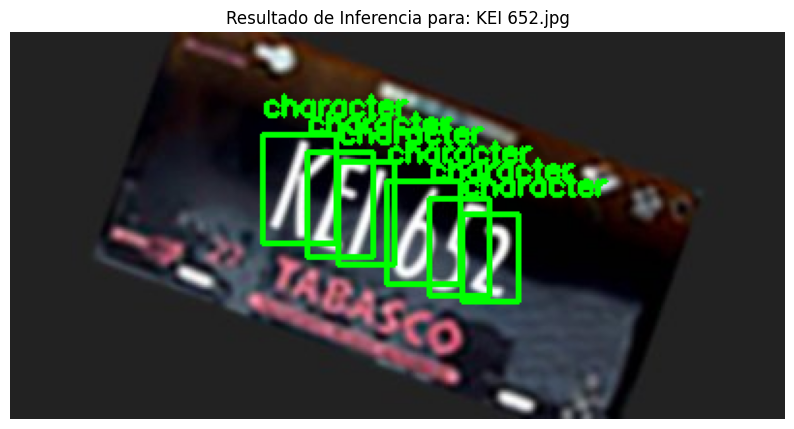

In [29]:
# Comando "mágico" para asegurar que los plots se muestren en el notebook
%matplotlib inline 

from random import random
import cv2
from sympy import Range
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path
import os

# --- 1. CONFIGURACIÓN ---
# ⚠️ ¡AJUSTA ESTAS DOS RUTAS! ⚠️

# Ruta al modelo entrenado. Encuéntrala en tu carpeta de proyecto,
# usualmente dentro de: runs/detect/train/weights/best.pt
MODEL_PATH = "best.pt"

import random

# Puedes cambiar el índice para probar diferentes imágenes
test_image_index = random.randint(0, len(val_files) - 1)  # Prueba la primera imagen del conjunto de validación
test_image_path = str(Path(val_files[test_image_index]).with_suffix(".jpg")) # Asegura la extensión .jpg



# Ruta a la imagen que quieres probar. Puede ser CUALQUIER imagen de placa.
TEST_IMAGE_PATH = test_image_path


# --------------------------

# Verificar que las rutas existan
if not os.path.exists(MODEL_PATH):
    print(f"🚨 ERROR: No se encuentra el archivo del modelo en '{MODEL_PATH}'")
    print("Verifica la ruta en la carpeta 'runs/detect/train...'")
elif not os.path.exists(TEST_IMAGE_PATH):
    print(f"🚨 ERROR: No se encuentra la imagen de prueba en '{TEST_IMAGE_PATH}'")
else:
    # Cargar el modelo entrenado
    print(f"Cargando modelo desde: {MODEL_PATH}")
    model = YOLO(MODEL_PATH)
    print("✅ Modelo cargado.")

    # Realizar la inferencia en la imagen
    print(f"Realizando inferencia en: {TEST_IMAGE_PATH}")
    results_inference = model.predict(TEST_IMAGE_PATH)

    # Leer la imagen con OpenCV
    image = cv2.imread(TEST_IMAGE_PATH)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convertir a RGB para Matplotlib

    # Asegurarse de que se encontraron detecciones
    if len(results_inference) > 0 and len(results_inference[0].boxes) > 0:
        # Obtener las bounding boxes
        boxes = results_inference[0].boxes.xyxy.cpu().numpy()

        # Dibujar CADA bounding box encontrada en la imagen
        for box in boxes:
            # Las coordenadas de YOLO son en formato xyxy (x1, y1, x2, y2)
            x1, y1, x2, y2 = map(int, box)
            
            # Dibujar el rectángulo
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Verde, grosor 2

            # Agregar la etiqueta de la clase (hardcodeada, ya que solo hay una)
            label = "character"
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        print(f"✅ Se encontraron y dibujaron {len(boxes)} caracteres.")
    else:
        print("⚠️ No se detectaron caracteres en la imagen.")


    # Mostrar la imagen con las detecciones usando matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(f"Resultado de Inferencia para: {os.path.basename(TEST_IMAGE_PATH)}")
    plt.axis('off')  # Ocultar los ejes
    plt.show()

# Training YOLO for clasification

In [5]:
# Celda 11: Preparación y Entrenamiento del Modelo de CLASIFICACIÓN

# --- 1. CONFIGURACIÓN PARA EL MODELO DE CLASIFICACIÓN ---
# ⚠️ ¡AJUSTA ESTAS DOS RUTAS! ⚠️

# Ruta a la carpeta que contiene las subcarpetas de clases (ej: /dataset/A, /dataset/B, ...)
RUTA_ORIGEN_CLASES = Path(r"C:\Universidad\Seminario\Roberto_Plates\V5\Dataset\extracted_characters")

# Ruta donde se creará el nuevo dataset formateado para clasificación
RUTA_SALIDA_CLASES_YOLO = Path(r"C:\Universidad\Seminario\Roberto_Plates\V5\Dataset\dataset_yolo_clasificacion")
# ----------------------------------------------------------------

# Limpiar la carpeta de salida si ya existe para evitar datos mezclados
if RUTA_SALIDA_CLASES_YOLO.exists():
    print(f"Borrando carpeta de salida antigua: {RUTA_SALIDA_CLASES_YOLO}")
    shutil.rmtree(RUTA_SALIDA_CLASES_YOLO)

# --- 2. PREPARACIÓN DE DATOS (ESTILO CLASIFICACIÓN YOLO) ---
print("\n📦 Creando estructura de carpetas para clasificación...")

# Crear las carpetas base 'train' y 'val'
ruta_train = RUTA_SALIDA_CLASES_YOLO / 'train'
ruta_val = RUTA_SALIDA_CLASES_YOLO / 'val'
ruta_train.mkdir(parents=True, exist_ok=True)
ruta_val.mkdir(parents=True, exist_ok=True)

# Obtener la lista de clases (nombres de las subcarpetas)
try:
    clases = [d.name for d in RUTA_ORIGEN_CLASES.iterdir() if d.is_dir()]
    if not clases:
        raise FileNotFoundError
    print(f"Clases encontradas: {len(clases)} -> {clases}")
except FileNotFoundError:
    print(f"🚨 ERROR: No se encontraron subcarpetas de clases en '{RUTA_ORIGEN_CLASES}'.")
    print("Asegúrate de que la ruta es correcta y contiene carpetas con imágenes.")
    clases = [] # Evita que el resto del script falle

# Procesar cada clase
for clase in tqdm(clases, desc="Procesando clases"):
    # Crear subcarpetas de clase en train y val
    (ruta_train / clase).mkdir()
    (ruta_val / clase).mkdir()

    # Obtener todas las imágenes para la clase actual
    ruta_clase_origen = RUTA_ORIGEN_CLASES / clase
    imagenes = list(ruta_clase_origen.glob('*.*')) # Acepta cualquier extensión

    # Dividir las imágenes en train y val
    train_imgs, val_imgs = train_test_split(imagenes, test_size=PORCENTAJE_VALIDACION, random_state=42)

    # Copiar imágenes a sus destinos
    for img_path in train_imgs:
        shutil.copy(img_path, ruta_train / clase / img_path.name)
    for img_path in val_imgs:
        shutil.copy(img_path, ruta_val / clase / img_path.name)

print("✅ Estructura de datos para clasificación creada exitosamente.")

Borrando carpeta de salida antigua: C:\Universidad\Seminario\Roberto_Plates\V5\Dataset\dataset_yolo_clasificacion

📦 Creando estructura de carpetas para clasificación...
Clases encontradas: 37 -> ['-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


Procesando clases:   0%|          | 0/37 [00:00<?, ?it/s]

✅ Estructura de datos para clasificación creada exitosamente.


In [9]:
from random import random
import cv2
from sympy import Range
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path
import os

# --- 3. ENTRENAMIENTO DEL MODELO DE CLASIFICACIÓN ---
if clases: # Solo intentar entrenar si se encontraron clases
    print("\n🚀 Iniciando entrenamiento del modelo de clasificación...")
    
    # Cargar un modelo de clasificación pre-entrenado (ej. yolov8n-cls.pt)
    # El usuario mencionó yolo11n-cls.pt, pero yolov8n-cls.pt es más común.
    # YOLO descargará el modelo si no lo encuentra localmente.
    model_cls = YOLO("yolov8x-cls.pt")

    # Iniciar el entrenamiento
    # Para clasificación, solo necesitamos apuntar a la carpeta raíz del dataset.
    # YOLO encontrará automáticamente las carpetas 'train' y 'val'.
    results_cls = model_cls.train(
        data=str(RUTA_SALIDA_CLASES_YOLO),
        epochs=100,  # Puedes ajustar las épocas
        imgsz=64,   # Las imágenes de caracteres son pequeñas, 64 puede ser suficiente
        batch=128,
        name="entrenamiento_CLASIFICACION_caracteres_v1" # Nombre para la carpeta de resultados
    )

    print("\n🎉 ¡Entrenamiento de clasificación completado!")
    print(f"Tus resultados están en: {results_cls.save_dir}")
    print(f"El mejor modelo está en: {results_cls.save_dir / 'weights' / 'best.pt'}")
else:
    print("\n⚠️ Entrenamiento omitido porque no se procesaron datos.")


🚀 Iniciando entrenamiento del modelo de clasificación...
New https://pypi.org/project/ultralytics/8.3.204 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.200  Python-3.10.11 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Universidad\Seminario\Roberto_Plates\V5\Dataset\dataset_yolo_clasificacion, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.